In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/student_dropout_project'
os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/data/raw', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/data/processed', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/models', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/reports', exist_ok=True)

Mounted at /content/drive


In [2]:
!pip install shap -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import shap
import joblib

In [3]:
import urllib.request, zipfile

url = "https://archive.ics.uci.edu/static/public/349/open+university+learning+analytics+dataset.zip"
zip_path = f'{PROJECT_DIR}/data/raw/oulad.zip'

urllib.request.urlretrieve(url, zip_path)

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(f'{PROJECT_DIR}/data/raw/')

print(os.listdir(f'{PROJECT_DIR}/data/raw/'))

['oulad.zip', 'assessments.csv', 'courses.csv', 'studentAssessment.csv', 'studentInfo.csv', 'studentRegistration.csv', 'studentVle.csv', 'vle.csv', 'OULAD.names']


In [5]:
data_path = f'{PROJECT_DIR}/data/raw/'

studentInfo = pd.read_csv(data_path + 'studentInfo.csv')
studentRegistration = pd.read_csv(data_path + 'studentRegistration.csv')
courses = pd.read_csv(data_path + 'courses.csv')
assessments = pd.read_csv(data_path + 'assessments.csv')
studentAssessment = pd.read_csv(data_path + 'studentAssessment.csv')
vle = pd.read_csv(data_path + 'vle.csv')
studentVLE = pd.read_csv(data_path + 'studentVle.csv')

tables = {
    'studentInfo': studentInfo, 'studentRegistration': studentRegistration,
    'courses': courses, 'assessments': assessments,
    'studentAssessment': studentAssessment, 'vle': vle, 'studentVLE': studentVLE
}

for name, df in tables.items():
    print(f"{name}: shape={df.shape}")

studentInfo: shape=(32593, 12)
studentRegistration: shape=(32593, 5)
courses: shape=(22, 3)
assessments: shape=(206, 6)
studentAssessment: shape=(173912, 5)
vle: shape=(6364, 6)
studentVLE: shape=(10655280, 6)


In [6]:
print(studentInfo['final_result'].value_counts())
print(studentInfo['final_result'].value_counts(normalize=True))

final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64
final_result
Pass           0.379253
Withdrawn      0.311601
Fail           0.216365
Distinction    0.092781
Name: proportion, dtype: float64


Phase 1: Data understanding and cleaning

In [7]:
for name, df in tables.items():
    print(f"\n{'='*50}\n{name}\n{'='*50}")
    print(df.dtypes)
    print(df.head(2))


studentInfo
code_module             object
code_presentation       object
id_student               int64
gender                  object
region                  object
highest_education       object
imd_band                object
age_band                object
num_of_prev_attempts     int64
studied_credits          int64
disability              object
final_result            object
dtype: object
  code_module code_presentation  id_student gender               region  \
0         AAA             2013J       11391      M  East Anglian Region   
1         AAA             2013J       28400      F             Scotland   

  highest_education imd_band age_band  num_of_prev_attempts  studied_credits  \
0  HE Qualification  90-100%     55<=                     0              240   
1  HE Qualification   20-30%    35-55                     0               60   

  disability final_result  
0          N         Pass  
1          N         Pass  

studentRegistration
code_module            object

In [8]:
for name, df in tables.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(f"\n{name} missing values:")
        print(missing)
        print(f"% missing: {(missing/len(df)*100).round(2)}")
    else:
        print(f"{name}: no missing values")

studentInfo: no missing values
studentRegistration: no missing values
courses: no missing values
assessments: no missing values
studentAssessment: no missing values
vle: no missing values
studentVLE: no missing values


In [9]:
studentInfo['dropout'] = (studentInfo['final_result'] == 'Withdrawn').astype(int)

print(studentInfo['dropout'].value_counts())
print(studentInfo.groupby('dropout')['final_result'].value_counts())

dropout
0    22437
1    10156
Name: count, dtype: int64
dropout  final_result
0        Pass            12361
         Fail             7052
         Distinction      3024
1        Withdrawn       10156
Name: count, dtype: int64


In [10]:
studentRegistration['date_unregistration'] = pd.to_numeric(
    studentRegistration['date_unregistration'], errors='coerce'
)

reg_check = studentRegistration.merge(
    studentInfo[['id_student','code_module','code_presentation','dropout']],
    on=['id_student','code_module','code_presentation']
)

print(reg_check.groupby('dropout')['date_unregistration'].describe())

           count       mean        std    min  25%   50%    75%    max
dropout                                                               
0            9.0  17.222222  55.847511   -7.0  0.0   0.0    0.0  166.0
1        10063.0  49.786744  82.476985 -365.0 -2.0  27.0  109.0  444.0


In [14]:
cutoff_day = 21  # 8 weeks

early_withdrawals = reg_check[
    (reg_check['dropout'] == 1) &
    (reg_check['date_unregistration'] < cutoff_day)
]

print(f"Withdrawals before day {cutoff_day}: {len(early_withdrawals)}")
print(f"Total withdrawals: {reg_check['dropout'].sum()}")
print(f"% withdrawing before cutoff: {len(early_withdrawals)/reg_check['dropout'].sum()*100:.1f}%")

Withdrawals before day 21: 4672
Total withdrawals: 10156
% withdrawing before cutoff: 46.0%


In [15]:
valid_students = reg_check[
    (reg_check['dropout'] == 0) |
    (reg_check['date_unregistration'] >= cutoff_day) |
    (reg_check['date_unregistration'].isna())
].copy()

print(f"Valid students for early-warning modeling: {len(valid_students)}")
print(f"Dropout rate in valid population: {valid_students['dropout'].mean():.3f}")

Valid students for early-warning modeling: 27921
Dropout rate in valid population: 0.196


Phase 2: Feature engineering

Step 1: Behavioral features from studentVLE (clicks before day 21)

In [16]:
cutoff_day = 21

vle_early = studentVLE[studentVLE['date'] < cutoff_day].copy()

behavioral_features = vle_early.groupby(
    ['id_student', 'code_module', 'code_presentation']
).agg(
    total_clicks=('sum_click', 'sum'),
    total_sessions=('date', 'nunique'),
    first_active_day=('date', 'min'),
    last_active_day=('date', 'max')
).reset_index()

behavioral_features['activity_span'] = (
    behavioral_features['last_active_day'] - behavioral_features['first_active_day']
)
behavioral_features['avg_clicks_per_day'] = (
    behavioral_features['total_clicks'] / behavioral_features['total_sessions']
)

print(behavioral_features.shape)
behavioral_features.head()

(28567, 9)


,id_student,code_module,code_presentation,total_clicks,total_sessions,first_active_day,last_active_day,activity_span,avg_clicks_per_day
0,6516,AAA,2014J,606,24,-23,20,43,25.2500
1,8462,DDD,2013J,317,16,-6,15,21,19.8125
2,8462,DDD,2014J,10,1,10,10,0,10.0000
3,11391,AAA,2013J,401,8,-5,18,23,50.1250
4,23629,BBB,2013B,51,5,-6,17,23,10.2000


Step 2: Academic features from studentAssessment + assessments (before day 21)

In [23]:
assessments = pd.read_csv(f'{PROJECT_DIR}/data/raw/assessments.csv')
studentAssessment = pd.read_csv(f'{PROJECT_DIR}/data/raw/studentAssessment.csv')

print("assessments columns:", assessments.columns.tolist())
print("studentAssessment columns:", studentAssessment.columns.tolist())

assessments['date'] = pd.to_numeric(assessments['date'], errors='coerce')
studentAssessment['date_submitted'] = pd.to_numeric(studentAssessment['date_submitted'], errors='coerce')
studentAssessment['score'] = pd.to_numeric(studentAssessment['score'], errors='coerce')

assessments_renamed = assessments.rename(columns={'date': 'date_due'})
assessments_renamed = assessments_renamed[['id_assessment', 'code_module', 'code_presentation', 'date_due']]
print("assessments_renamed columns:", assessments_renamed.columns.tolist())

assessments_with_dates = studentAssessment.merge(assessments_renamed, on='id_assessment', how='left')
print("merged columns:", assessments_with_dates.columns.tolist())

cutoff_day = 21

assessments_early = assessments_with_dates[
    assessments_with_dates['date_submitted'] < cutoff_day
].copy()

academic_features = assessments_early.groupby(
    ['id_student', 'code_module', 'code_presentation']
).agg(
    num_assessments_submitted=('id_assessment', 'count'),
    avg_score=('score', 'mean'),
    min_score=('score', 'min'),
    num_low_scores=('score', lambda x: (x < 40).sum()),
    avg_submission_delay=('date_submitted', lambda x: (x - assessments_early.loc[x.index, 'date_due']).mean())
).reset_index()

print(academic_features.shape)
academic_features.head()

assessments columns: ['code_module', 'code_presentation', 'id_assessment', 'assessment_type', 'date', 'weight']
studentAssessment columns: ['id_assessment', 'id_student', 'date_submitted', 'is_banked', 'score']
assessments_renamed columns: ['id_assessment', 'code_module', 'code_presentation', 'date_due']
merged columns: ['id_assessment', 'id_student', 'date_submitted', 'is_banked', 'score', 'code_module', 'code_presentation', 'date_due']
(13623, 8)


,id_student,code_module,code_presentation,num_assessments_submitted,avg_score,min_score,num_low_scores,avg_submission_delay
0,6516,AAA,2014J,1,60.0,60.0,0,-2.0
1,8462,DDD,2014J,4,86.5,83.0,0,-59.5
2,11391,AAA,2013J,1,78.0,78.0,0,-1.0
3,23629,BBB,2013B,1,67.0,67.0,0,-10.0
4,23798,BBB,2013J,1,90.0,90.0,0,-1.0


Step 3: Demographic features from studentInfo

In [24]:
demographic_features = studentInfo[[
    'id_student', 'code_module', 'code_presentation',
    'gender', 'age_band', 'region', 'highest_education',
    'imd_band', 'num_of_prev_attempts', 'studied_credits', 'disability'
]].copy()

print(demographic_features.shape)
demographic_features.head()

(32593, 11)


,id_student,code_module,code_presentation,gender,age_band,region,highest_education,imd_band,num_of_prev_attempts,studied_credits,disability
0,11391,AAA,2013J,M,55<=,East Anglian Region,HE Qualification,90-100%,0,240,N
1,28400,AAA,2013J,F,35-55,Scotland,HE Qualification,20-30%,0,60,N
2,30268,AAA,2013J,F,35-55,North Western Region,A Level or Equivalent,30-40%,0,60,Y
3,31604,AAA,2013J,F,35-55,South East Region,A Level or Equivalent,50-60%,0,60,N
4,32885,AAA,2013J,F,0-35,West Midlands Region,Lower Than A Level,50-60%,0,60,N


Step 4: Merge all feature blocks onto the valid_students base table

In [25]:
final_features = valid_students[[
    'id_student', 'code_module', 'code_presentation', 'dropout'
]].copy()

final_features = final_features.merge(
    behavioral_features, on=['id_student', 'code_module', 'code_presentation'], how='left'
)
final_features = final_features.merge(
    academic_features, on=['id_student', 'code_module', 'code_presentation'], how='left'
)
final_features = final_features.merge(
    demographic_features, on=['id_student', 'code_module', 'code_presentation'], how='left'
)

print(final_features.shape)
final_features.head()

(27921, 23)


,id_student,code_module,code_presentation,dropout,total_clicks,total_sessions,first_active_day,last_active_day,activity_span,avg_clicks_per_day,...,num_low_scores,avg_submission_delay,gender,age_band,region,highest_education,imd_band,num_of_prev_attempts,studied_credits,disability
0,11391,AAA,2013J,0,401.0,8.0,-5.0,18.0,23.0,50.125000,...,0.0,-1.0,M,55<=,East Anglian Region,HE Qualification,90-100%,0,240,N
1,28400,AAA,2013J,0,493.0,15.0,-10.0,16.0,26.0,32.866667,...,NaN,NaN,F,35-55,Scotland,HE Qualification,20-30%,0,60,N
2,31604,AAA,2013J,0,453.0,17.0,-10.0,20.0,30.0,26.647059,...,0.0,-2.0,F,35-55,South East Region,A Level or Equivalent,50-60%,0,60,N
3,32885,AAA,2013J,0,509.0,20.0,-10.0,20.0,30.0,25.450000,...,NaN,NaN,F,0-35,West Midlands Region,Lower Than A Level,50-60%,0,60,N
4,38053,AAA,2013J,0,688.0,28.0,-10.0,20.0,30.0,24.571429,...,0.0,0.0,M,35-55,Wales,A Level or Equivalent,80-90%,0,60,N


Step 5: Handle missing values from the merge (students with zero activity/assessments before day 21)

In [26]:
print(final_features.isnull().sum())

behavioral_cols = ['total_clicks', 'total_sessions', 'activity_span', 'avg_clicks_per_day']
academic_cols = ['num_assessments_submitted', 'avg_score', 'min_score', 'num_low_scores', 'avg_submission_delay']

final_features[behavioral_cols] = final_features[behavioral_cols].fillna(0)
final_features[academic_cols] = final_features[academic_cols].fillna(0)

final_features['first_active_day'] = final_features['first_active_day'].fillna(-1)
final_features['last_active_day'] = final_features['last_active_day'].fillna(-1)

print(final_features.isnull().sum())

id_student                       0
code_module                      0
code_presentation                0
dropout                          0
total_clicks                  1214
total_sessions                1214
first_active_day              1214
last_active_day               1214
activity_span                 1214
avg_clicks_per_day            1214
num_assessments_submitted    14486
avg_score                    14491
min_score                    14491
num_low_scores               14486
avg_submission_delay         14486
gender                           0
age_band                         0
region                           0
highest_education                0
imd_band                         0
num_of_prev_attempts             0
studied_credits                  0
disability                       0
dtype: int64
id_student                   0
code_module                  0
code_presentation            0
dropout                      0
total_clicks                 0
total_sessions             

Step 6: Save the final feature table

In [27]:
final_features.to_csv(f'{PROJECT_DIR}/data/processed/final_features.csv', index=False)
print(f"Final dataset shape: {final_features.shape}")
print(final_features['dropout'].value_counts(normalize=True))

Final dataset shape: (27921, 23)
dropout
0    0.803589
1    0.196411
Name: proportion, dtype: float64


Phase 3: Exploratory analysis

In [28]:
final_features = pd.read_csv(f'{PROJECT_DIR}/data/processed/final_features.csv')

numeric_cols = [
    'total_clicks', 'total_sessions', 'activity_span', 'avg_clicks_per_day',
    'num_assessments_submitted', 'avg_score', 'min_score', 'num_low_scores',
    'avg_submission_delay', 'num_of_prev_attempts', 'studied_credits'
]

comparison = final_features.groupby('dropout')[numeric_cols].mean().T
comparison.columns = ['Non-Dropout (0)', 'Dropout (1)']
comparison['% Difference'] = (
    (comparison['Dropout (1)'] - comparison['Non-Dropout (0)']) / comparison['Non-Dropout (0)'] * 100
).round(1)

print(comparison)

for col in ['gender', 'age_band', 'highest_education', 'disability']:
    print(f"\n{col} vs dropout rate:")
    print(final_features.groupby(col)['dropout'].mean().sort_values(ascending=False))

correlations = final_features[numeric_cols + ['dropout']].corr()['dropout'].sort_values(ascending=False)
print("\nCorrelation with dropout:")
print(correlations)

                           Non-Dropout (0)  Dropout (1)  % Difference
total_clicks                    303.559834   228.881291         -24.6
total_sessions                   12.023221    10.154085         -15.5
activity_span                    25.679324    24.404632          -5.0
avg_clicks_per_day               21.323642    19.133644         -10.3
num_assessments_submitted         0.598699     0.440190         -26.5
avg_score                        37.342917    24.468619         -34.5
min_score                        36.961715    24.156273         -34.6
num_low_scores                    0.034274     0.053428          55.9
avg_submission_delay             -9.889527    -5.555908         -43.8
num_of_prev_attempts              0.152605     0.191831          25.7
studied_credits                  74.475643    84.913384          14.0

gender vs dropout rate:
gender
M    0.206953
F    0.183465
Name: dropout, dtype: float64

age_band vs dropout rate:
age_band
0-35     0.200627
35-55    0.18701

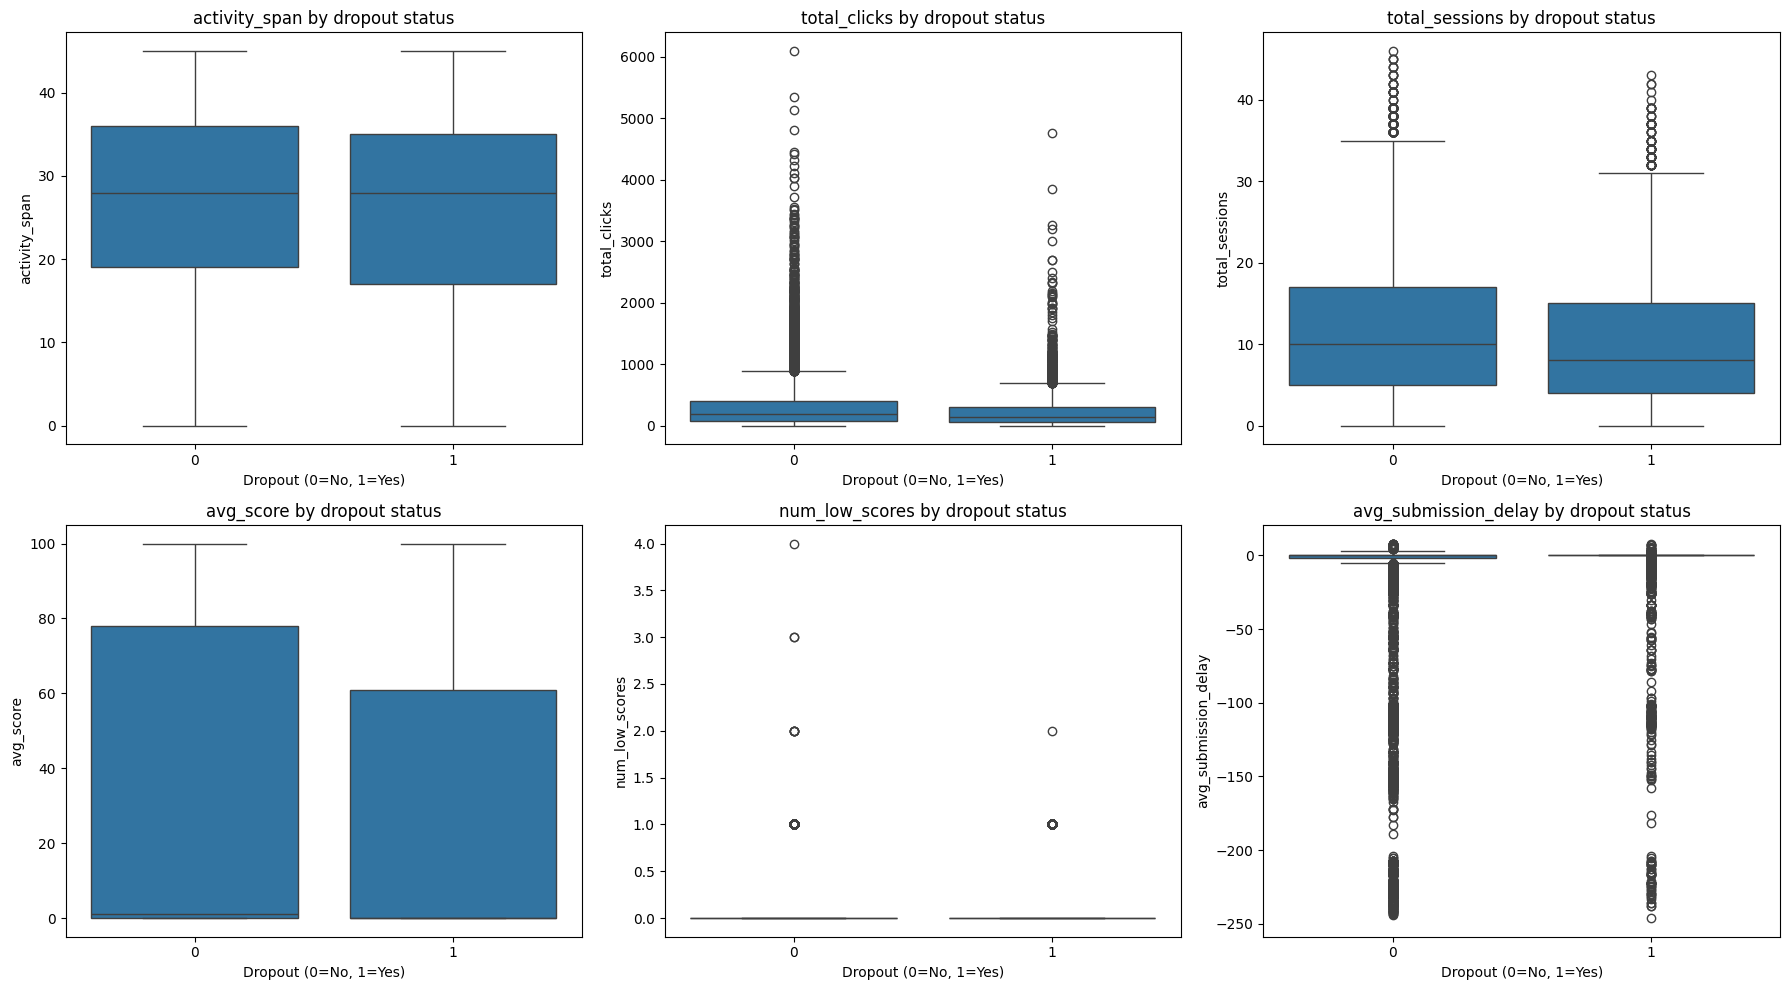

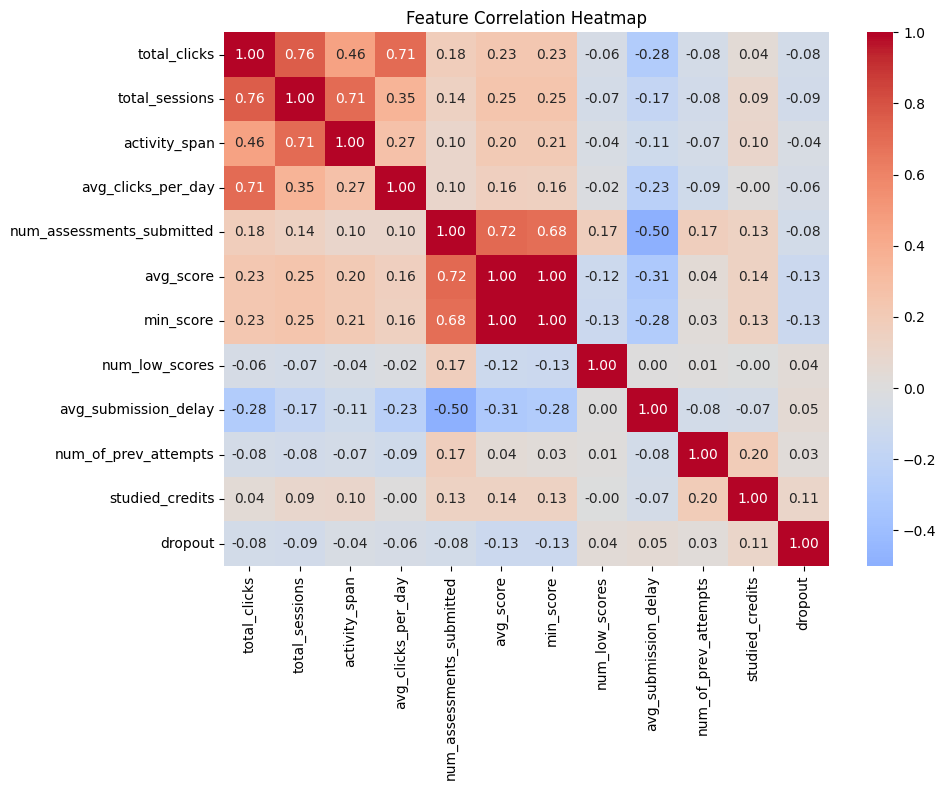

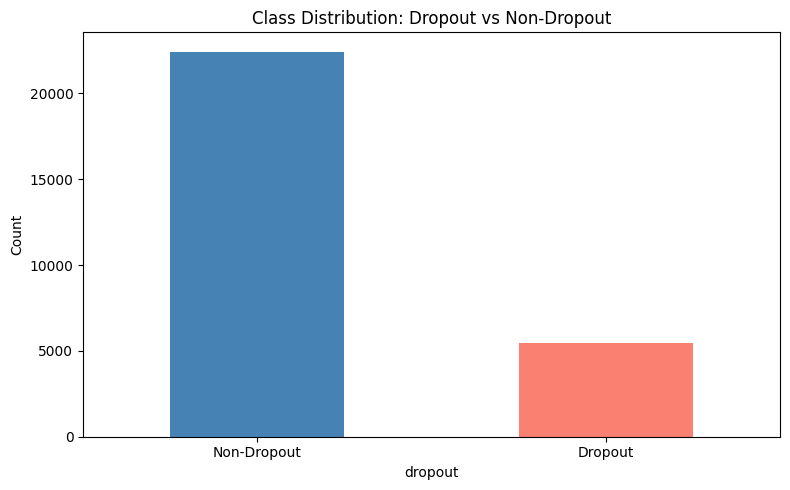

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

key_features = ['activity_span', 'total_clicks', 'total_sessions', 'avg_score', 'num_low_scores', 'avg_submission_delay']

for ax, col in zip(axes.flatten(), key_features):
    sns.boxplot(data=final_features, x='dropout', y=col, ax=ax)
    ax.set_title(f'{col} by dropout status')
    ax.set_xlabel('Dropout (0=No, 1=Yes)')

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/reports/feature_boxplots.png', dpi=150)
plt.show()

plt.figure(figsize=(10, 8))
corr_matrix = final_features[numeric_cols + ['dropout']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/reports/correlation_heatmap.png', dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
final_features['dropout'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Class Distribution: Dropout vs Non-Dropout')
plt.xticks([0, 1], ['Non-Dropout', 'Dropout'], rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/reports/class_distribution.png', dpi=150)
plt.show()

Phase 4: Baseline modeling

AUC-ROC: 0.642276598631497

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.61      0.71      4488
           1       0.27      0.59      0.37      1097

    accuracy                           0.61      5585
   macro avg       0.56      0.60      0.54      5585
weighted avg       0.74      0.61      0.65      5585


Confusion Matrix:
[[2734 1754]
 [ 450  647]]


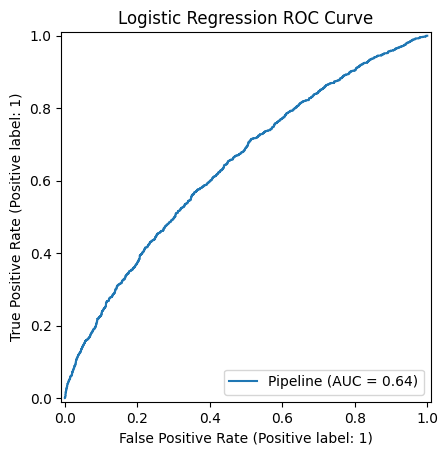

['/content/drive/MyDrive/student_dropout_project/models/logreg_baseline.pkl']

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay
import joblib

categorical_cols = ['gender', 'age_band', 'region', 'highest_education', 'imd_band', 'disability']
numeric_features = [
    'total_clicks', 'total_sessions', 'activity_span', 'avg_clicks_per_day',
    'num_assessments_submitted', 'avg_score', 'min_score', 'num_low_scores',
    'avg_submission_delay', 'num_of_prev_attempts', 'studied_credits'
]

X = final_features[numeric_features + categorical_cols]
y = final_features['dropout']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols)
])

logreg_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42))
])

logreg_pipeline.fit(X_train, y_train)

y_pred = logreg_pipeline.predict(X_test)
y_pred_proba = logreg_pipeline.predict_proba(X_test)[:, 1]

print("AUC-ROC:", roc_auc_score(y_test, y_pred_proba))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

RocCurveDisplay.from_estimator(logreg_pipeline, X_test, y_test)
plt.title('Logistic Regression ROC Curve')
plt.savefig(f'{PROJECT_DIR}/reports/logreg_roc_curve.png', dpi=150)
plt.show()

joblib.dump(logreg_pipeline, f'{PROJECT_DIR}/models/logreg_baseline.pkl')

Phase 5: Random Forest and SVM

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best RF params: {'classifier__max_depth': 12, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Best RF CV AUC: 0.676935969483672

--- Random Forest Test Results ---
AUC-ROC: 0.6806650003168584
              precision    recall  f1-score   support

           0       0.86      0.75      0.80      4488
           1       0.32      0.49      0.39      1097

    accuracy                           0.70      5585
   macro avg       0.59      0.62      0.60      5585
weighted avg       0.75      0.70      0.72      5585

[[3360 1128]
 [ 556  541]]

--- SVM Test Results ---
AUC-ROC: 0.6765317256429382
              precision    recall  f1-score   support

           0       0.87      0.69      0.77      4488
           1       0.31      0.57      0.40      1097

    accuracy                           0.67      5585
   macro avg       0.59      0.63      0.58      5585
weighted a

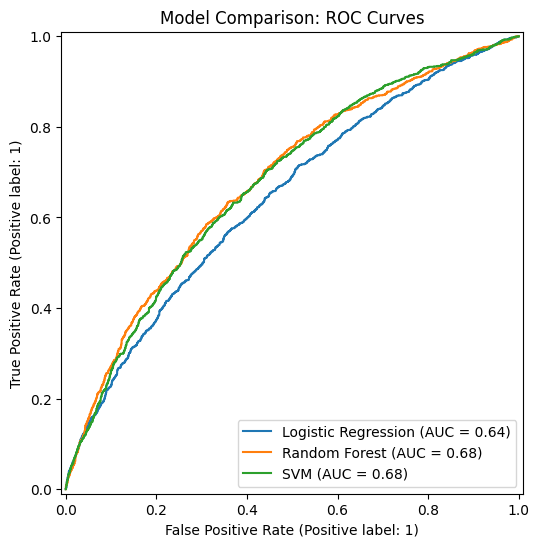

['/content/drive/MyDrive/student_dropout_project/models/svm_baseline.pkl']

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42))
])

rf_param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [8, 12, None],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_grid = GridSearchCV(
    rf_pipeline, rf_param_grid, scoring='roc_auc', cv=cv, n_jobs=-1, verbose=1
)
rf_grid.fit(X_train, y_train)

print("Best RF params:", rf_grid.best_params_)
print("Best RF CV AUC:", rf_grid.best_score_)

rf_best = rf_grid.best_estimator_
y_pred_rf = rf_best.predict(X_test)
y_pred_proba_rf = rf_best.predict_proba(X_test)[:, 1]

print("\n--- Random Forest Test Results ---")
print("AUC-ROC:", roc_auc_score(y_test, y_pred_proba_rf))
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

svm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42))
])

svm_pipeline.fit(X_train, y_train)

y_pred_svm = svm_pipeline.predict(X_test)
y_pred_proba_svm = svm_pipeline.predict_proba(X_test)[:, 1]

print("\n--- SVM Test Results ---")
print("AUC-ROC:", roc_auc_score(y_test, y_pred_proba_svm))
print(classification_report(y_test, y_pred_svm))
print(confusion_matrix(y_test, y_pred_svm))

fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(logreg_pipeline, X_test, y_test, ax=ax, name='Logistic Regression')
RocCurveDisplay.from_estimator(rf_best, X_test, y_test, ax=ax, name='Random Forest')
RocCurveDisplay.from_estimator(svm_pipeline, X_test, y_test, ax=ax, name='SVM')
plt.title('Model Comparison: ROC Curves')
plt.savefig(f'{PROJECT_DIR}/reports/model_comparison_roc.png', dpi=150)
plt.show()

joblib.dump(rf_best, f'{PROJECT_DIR}/models/random_forest_best.pkl')
joblib.dump(svm_pipeline, f'{PROJECT_DIR}/models/svm_baseline.pkl')

Phase 6: Model interpretability

Top 15 Logistic Regression features by absolute coefficient:
                                          feature  coefficient
28              highest_education_No Formal quals     0.648907
39                                     imd_band_?    -0.425144
40                                   disability_Y     0.421951
10                                studied_credits     0.305619
27           highest_education_Lower Than A Level     0.273289
38                               imd_band_90-100%    -0.255083
29  highest_education_Post Graduate Qualification     0.250795
1                                  total_sessions    -0.235808
6                                       min_score    -0.215014
34                                imd_band_50-60%    -0.207440
13                                  age_band_55<=     0.202424
37                                imd_band_80-90%    -0.198967
15                                 region_Ireland     0.187935
36                                imd_band_70-80%    -0.1

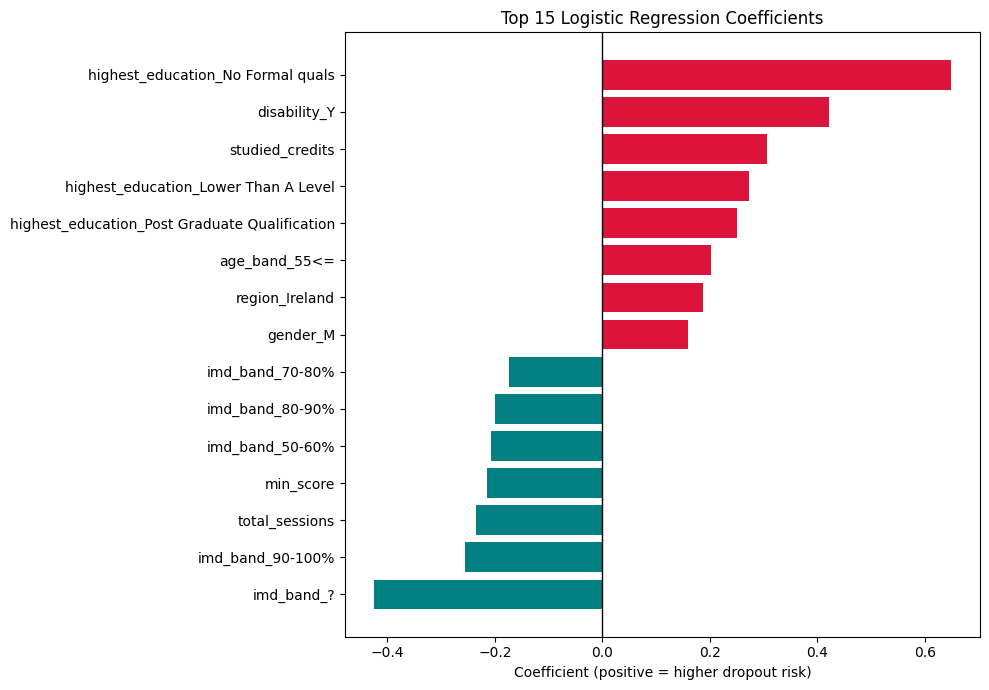

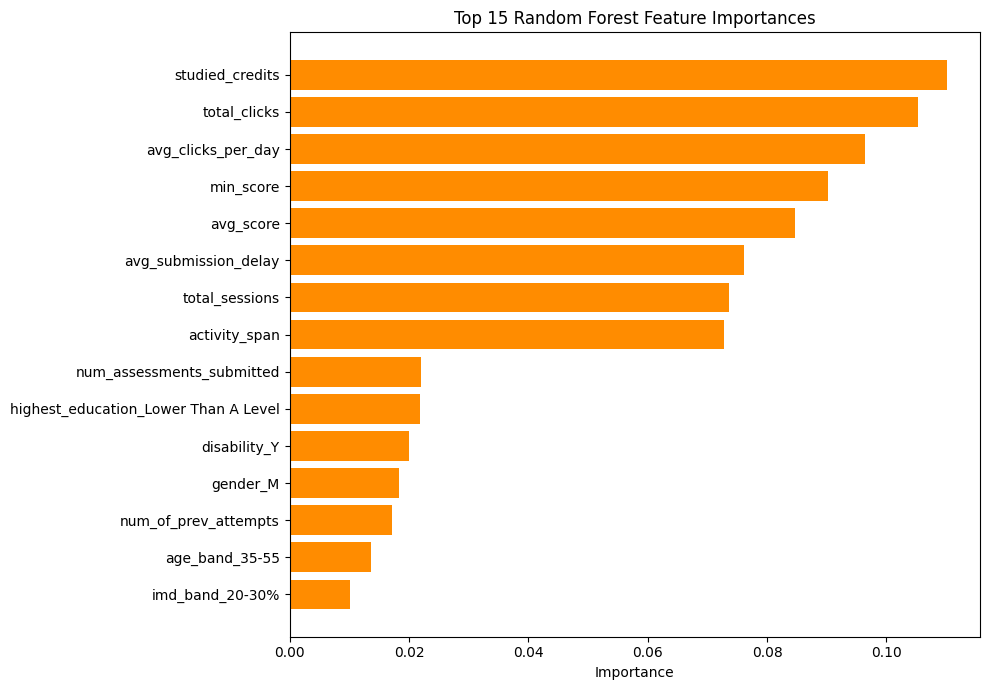

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract transformed feature names
ohe = logreg_pipeline.named_steps['preprocessor'].named_transformers_['cat']
encoded_cat_names = ohe.get_feature_names_out(categorical_cols).tolist()
all_feature_names = numeric_features + encoded_cat_names

# 2. Logistic Regression coefficients
logreg_model = logreg_pipeline.named_steps['classifier']
logreg_coefs = pd.DataFrame({
    'feature': all_feature_names,
    'coefficient': logreg_model.coef_[0]
})

logreg_coefs['abs_coefficient'] = logreg_coefs['coefficient'].abs()
logreg_coefs = logreg_coefs.sort_values('abs_coefficient', ascending=False)

print("Top 15 Logistic Regression features by absolute coefficient:")
print(logreg_coefs[['feature', 'coefficient']].head(15))

# 3. Random Forest feature importance
rf_model = rf_best.named_steps['classifier']
rf_importance = pd.DataFrame({
    'feature': all_feature_names,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 15 Random Forest important features:")
print(rf_importance.head(15))

# 4. Save coefficient/importance tables
logreg_coefs.to_csv(f'{PROJECT_DIR}/reports/logreg_coefficients.csv', index=False)
rf_importance.to_csv(f'{PROJECT_DIR}/reports/random_forest_feature_importance.csv', index=False)

#  5. Plot top 15 Logistic Regression coefficients
top_logreg = logreg_coefs.sort_values('abs_coefficient', ascending=False).head(15).copy()
top_logreg = top_logreg.sort_values('coefficient')

plt.figure(figsize=(10, 7))
colors = ['crimson' if x > 0 else 'teal' for x in top_logreg['coefficient']]
plt.barh(top_logreg['feature'], top_logreg['coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=1)
plt.title('Top 15 Logistic Regression Coefficients')
plt.xlabel('Coefficient (positive = higher dropout risk)')
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/reports/logreg_top_coefficients.png', dpi=150)
plt.show()

# 6. Plot top 15 Random Forest importances
top_rf = rf_importance.head(15).sort_values('importance')

plt.figure(figsize=(10, 7))
plt.barh(top_rf['feature'], top_rf['importance'], color='darkorange')
plt.title('Top 15 Random Forest Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/reports/rf_top_importances.png', dpi=150)
plt.show()

Phase 7: Threshold tuning and early-warning interpretation

           model  threshold  precision    recall        f1  true_positives  \
0  Random Forest        0.2   0.199926  0.985415  0.332411            1081   
1  Random Forest        0.3   0.226251  0.898815  0.361503             986   
2  Random Forest        0.4   0.279941  0.688241  0.397997             755   
3  Random Forest        0.5   0.324146  0.493163  0.391179             541   
4  Random Forest        0.6   0.388821  0.291705  0.333333             320   
5            SVM        0.2   0.304511  0.590702  0.401860             648   
6            SVM        0.3   0.359091  0.360073  0.359581             395   
7            SVM        0.4   0.453659  0.084777  0.142857              93   
8            SVM        0.5   0.500000  0.002735  0.005440               3   
9            SVM        0.6   0.000000  0.000000  0.000000               0   

   false_positives  false_negatives  true_negatives  students_flagged  
0             4326               16             162              5407

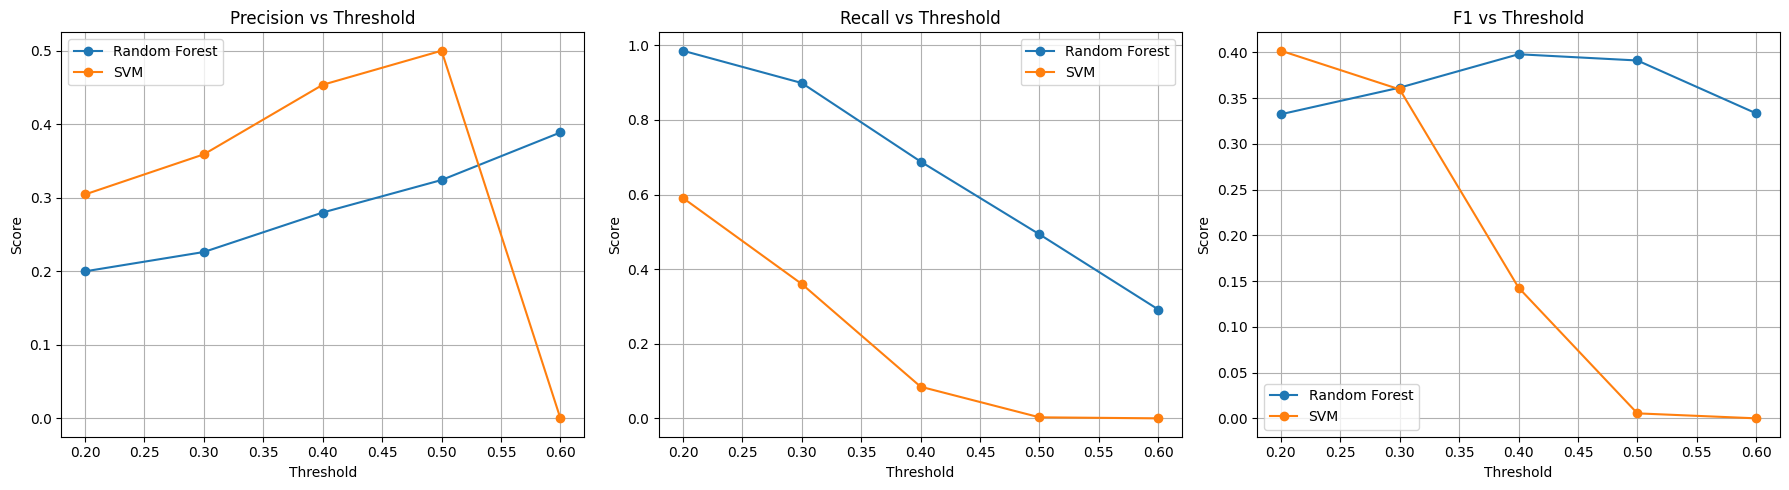


Best threshold per model by F1:
           model  threshold  precision    recall        f1  true_positives  \
2  Random Forest        0.4   0.279941  0.688241  0.397997             755   
5            SVM        0.2   0.304511  0.590702  0.401860             648   

   false_positives  false_negatives  true_negatives  students_flagged  
2             1942              342            2546              2697  
5             1480              449            3008              2128  


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix


rf_probs = rf_best.predict_proba(X_test)[:, 1]
svm_probs = svm_pipeline.predict_proba(X_test)[:, 1]

thresholds = [0.20, 0.30, 0.40, 0.50, 0.60]

results = []

for model_name, probs in [('Random Forest', rf_probs), ('SVM', svm_probs)]:
    for th in thresholds:
        preds = (probs >= th).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

        results.append({
            'model': model_name,
            'threshold': th,
            'precision': precision_score(y_test, preds, zero_division=0),
            'recall': recall_score(y_test, preds, zero_division=0),
            'f1': f1_score(y_test, preds, zero_division=0),
            'true_positives': tp,
            'false_positives': fp,
            'false_negatives': fn,
            'true_negatives': tn,
            'students_flagged': int(preds.sum())
        })

threshold_df = pd.DataFrame(results)
print(threshold_df)

threshold_df.to_csv(f'{PROJECT_DIR}/reports/threshold_tuning_results.csv', index=False)

# Plot recall/precision/F1 vs threshold
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for model_name in threshold_df['model'].unique():
    temp = threshold_df[threshold_df['model'] == model_name]

    axes[0].plot(temp['threshold'], temp['precision'], marker='o', label=model_name)
    axes[1].plot(temp['threshold'], temp['recall'], marker='o', label=model_name)
    axes[2].plot(temp['threshold'], temp['f1'], marker='o', label=model_name)

axes[0].set_title('Precision vs Threshold')
axes[1].set_title('Recall vs Threshold')
axes[2].set_title('F1 vs Threshold')

for ax in axes:
    ax.set_xlabel('Threshold')
    ax.set_ylabel('Score')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/reports/threshold_tuning_curves.png', dpi=150)
plt.show()

# Optional: pick best threshold by F1
best_rows = threshold_df.loc[threshold_df.groupby('model')['f1'].idxmax()]
print("\nBest threshold per model by F1:")
print(best_rows)

In [38]:
import json
import joblib
from sklearn.metrics import classification_report, confusion_matrix

final_model = rf_best
final_threshold = 0.40

final_probabilities = final_model.predict_proba(X_test)[:, 1]
final_predictions = (final_probabilities >= final_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, final_predictions).ravel()

final_metrics = {
    'model': 'Random Forest',
    'threshold': final_threshold,
    'roc_auc': float(roc_auc_score(y_test, final_probabilities)),
    'precision_dropout': float(precision_score(y_test, final_predictions, zero_division=0)),
    'recall_dropout': float(recall_score(y_test, final_predictions, zero_division=0)),
    'f1_dropout': float(f1_score(y_test, final_predictions, zero_division=0)),
    'true_positives': int(tp),
    'false_positives': int(fp),
    'false_negatives': int(fn),
    'true_negatives': int(tn),
    'students_flagged': int(final_predictions.sum())
}

joblib.dump(final_model, f'{PROJECT_DIR}/models/final_dropout_model.pkl')

with open(f'{PROJECT_DIR}/models/final_model_config.json', 'w') as f:
    json.dump(final_metrics, f, indent=4)

print(json.dumps(final_metrics, indent=4))

{
    "model": "Random Forest",
    "threshold": 0.4,
    "roc_auc": 0.6806650003168584,
    "precision_dropout": 0.2799406748238784,
    "recall_dropout": 0.6882406563354604,
    "f1_dropout": 0.39799683711122824,
    "true_positives": 755,
    "false_positives": 1942,
    "false_negatives": 342,
    "true_negatives": 2546,
    "students_flagged": 2697
}
